In [8]:
from data_processing import load_data
from backtest import run_backtest
from mvo import *
from run_portfolio import compute_metrics

In [9]:
mu_baseline, mu_regime, daily_log_returns, cumulative_returns, rebalancing_datess = load_data("data/binance_data_raw.csv","outputs_draft/all_forecasts.csv")

In [10]:
# === make changes to data
import pandas as pd
import numpy as np

In [11]:
# === modify load_data
all_forecasts = pd.read_csv("outputs_draft/all_forecasts.csv", parse_dates=True)
df_hist = pd.read_csv("data/binance_data_raw.csv", parse_dates=True)

In [12]:
df_hist = df_hist[["date", "crypto", "log_return"]]

In [13]:
mu_baseline = all_forecasts[all_forecasts["model_type"] == "baseline"].pivot(index="date", columns="crypto", values="y_pred")
mu_regime   = all_forecasts[all_forecasts["model_type"] == "regime"].pivot(index="date", columns="crypto", values="y_pred")
daily_log_returns = df_hist.pivot(index="date", columns="crypto", values="log_return")

In [14]:
# compute 7d cumulative return
cumulative_returns = daily_log_returns.rolling(window=7).sum()
cumulative_returns

crypto,ADAUSDT,BCHUSDT,BNBUSDT,BTCUSDT,ETHUSDT,LINKUSDT,LTCUSDT,XRPUSDT
date,,,,,,,,
2020-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2025-12-20,-0.095798,0.020820,-0.048725,-0.021043,-0.044885,-0.089794,-0.045579,-0.045101
2025-12-21,-0.078992,0.057089,-0.021465,0.005505,-0.020273,-0.065342,-0.027867,-0.028766
2025-12-22,-0.045049,0.096480,0.000070,0.025008,0.014944,-0.021236,-0.005952,0.003261


In [15]:
# def load_data(hist_data_fp, forecast_fp):
#     all_forecasts = pd.read_csv(forecast_fp, parse_dates=True)

#     mu_baseline = all_forecasts[all_forecasts["model_type"] == "baseline"].pivot(index="date", columns="crypto", values="y_pred")
#     mu_regime   = all_forecasts[all_forecasts["model_type"] == "regime"].pivot(index="date", columns="crypto", values="y_pred")

#     df_hist = pd.read_csv(hist_data_fp, parse_dates=True)
#     df_hist = df_hist[["date", "crypto", "log_return"]] # daily log returns

#     # align dates and cryptos between forecasts and historical returns
#     start_date = max(mu_baseline.index.min(), mu_regime.index.min(), df_hist["date"].min())
#     end_date = min(mu_baseline.index.max(), mu_regime.index.max(), df_hist["date"].max())
#     df_hist = df_hist[(df_hist["date"] >= start_date) & (df_hist["date"] <= end_date)]
#     daily_log_returns = df_hist.pivot(index="date", columns="crypto", values="log_return")
#     cumulative_returns = daily_log_returns.rolling(window=7).sum() # compute backward looking 7d cumulative returns 
    
#     # keep only test dates for evaluation
#     test_dates = sorted(all_forecasts.loc[all_forecasts["split"] == "test", "date"].unique())
#     # take every 7th date to match weekly rebalancing
#     rebalancing_dates = test_dates[::7]
#     rebalancing_dates = pd.to_datetime(rebalancing_dates)
#     return mu_baseline, mu_regime, daily_log_returns, cumulative_returns, rebalancing_dates

In [16]:
mu_baseline, mu_regime, daily_log_returns, cumulative_returns, rebalancing_dates = load_data("data/binance_data_raw.csv", "outputs_draft/all_forecasts.csv")

In [17]:
print(f"===== Checking dates alignment =====")
print("Mu baseline dates:", mu_baseline.index.min(), "to", mu_baseline.index.max())
print("Mu regime dates:", mu_regime.index.min(), "to", mu_regime.index.max())
print("Daily log returns dates:", daily_log_returns.index.min(), "to", daily_log_returns.index.max())
print("Cumulative returns dates:", cumulative_returns.index.min(), "to", cumulative_returns.index.max())

===== Checking dates alignment =====
Mu baseline dates: 2024-01-01 to 2025-12-24
Mu regime dates: 2024-01-01 to 2025-12-24
Daily log returns dates: 2024-01-01 to 2025-12-24
Cumulative returns dates: 2024-01-01 to 2025-12-24


In [18]:
# # edit run_backtest
# mu = mu_baseline  # or mu_regime
# # real_returns = daily_log_returns
# # eval_dates = rebalancing_dates
# window = 4  # use past 4 weeks (28 days) of data for covariance estimation
# lamda = 0.1  # risk aversion parameter

# portfolio_returns = []
# weights_history = []

# dates = mu.index
# assets = mu.columns

In [19]:
rebalancing_dates[0].strftime('%Y-%m-%d')

'2025-01-01'

In [20]:
# for _ in sorted(rebalancing_dates):
# current_date = _.strftime('%Y-%m-%d')
# t_idx = cumulative_returns.index.get_loc(_.strftime('%Y-%m-%d'))
# # print(f"Processing date: {current_date} for ADAUSDT with data: {cumulative_returns["ADAUSDT"].iloc[t_idx]}")
# # compute 7d cumulative return up to current date for covariance estimation
# hist_7d = cumulative_returns.iloc[t_idx - (window-1)*7 : t_idx + 1 : 7]
# cov_t = hist_7d.cov().values
# mu_t = mu.loc[current_date].values # should by 7-day cumulative return forecasts (expected returns for the next 7 days)
# # print(f"Covariance matrix on {current_date}:\n{cov_t}")
# # print(f"mu_t on {current_date}:\n{mu_t}")
# w_t = optimize_portfolio(mu_t, cov_t, lamda=lamda)

# realised_7d = daily_log_returns.iloc[t_idx+1 : t_idx+8].sum(axis=0).values # actual return from holding period (next 7 days)
# portfolio_return = np.dot(w_t, realised_7d)
# portfolio_returns.append(portfolio_return)
# weights_history.append(w_t)

In [22]:
base_ret, base_w = run_backtest(
    mu_baseline,
    daily_log_returns,
    cumulative_returns,
    rebalancing_dates,
    window=20,
    lamda=5.0
)

reg_ret, reg_w = run_backtest(
    mu_regime,
    daily_log_returns,
    cumulative_returns,
    rebalancing_dates,
    window=20,
    lamda=5.0
)

Backtest at 2025-01-01 (index 366)
optimal weights at 2025-01-01: [0.00000000e+00 1.04083409e-16 3.00000000e-01 3.00000000e-01
 1.00000000e-01 0.00000000e+00 3.00000000e-01 0.00000000e+00]
portfolio return at 2025-01-01: -0.015616349909073924
Backtest at 2025-01-08 (index 373)
optimal weights at 2025-01-08: [1.54050501e-16 3.00000000e-01 1.00000000e-01 3.00000000e-01
 2.02642386e-16 3.00000000e-01 2.87096735e-16 2.20632190e-16]
portfolio return at 2025-01-08: 0.06011557774515893
Backtest at 2025-01-15 (index 380)
optimal weights at 2025-01-15: [1.69648145e-16 1.00000000e-01 3.00000000e-01 3.00000000e-01
 1.26541772e-17 3.00000000e-01 1.22084220e-16 0.00000000e+00]
portfolio return at 2025-01-15: 0.036322444009160904
Backtest at 2025-01-22 (index 387)
optimal weights at 2025-01-22: [0.00033762 0.         0.3        0.3        0.09966238 0.
 0.3        0.        ]
portfolio return at 2025-01-22: -0.014750367546978328
Backtest at 2025-01-29 (index 394)
optimal weights at 2025-01-29: [2.22

In [31]:
reg_w

crypto,ADAUSDT,BCHUSDT,BNBUSDT,BTCUSDT,ETHUSDT,LINKUSDT,LTCUSDT,XRPUSDT
2025-01-01,1.858615e-17,5.551115e-17,3.000000e-01,0.300000,1.000000e-01,4.981246e-17,3.000000e-01,8.198476e-17
2025-01-08,1.546945e-17,1.000000e-01,3.000000e-01,0.300000,3.000000e-01,0.000000e+00,0.000000e+00,2.564296e-16
2025-01-15,7.686644e-17,7.375747e-19,3.000000e-01,0.300000,1.000000e-01,3.000000e-01,1.170723e-16,1.917058e-16
2025-01-22,0.000000e+00,0.000000e+00,3.000000e-01,0.300000,1.000000e-01,0.000000e+00,3.000000e-01,0.000000e+00
2025-01-29,9.262809e-17,1.179612e-16,3.000000e-01,0.300000,1.343918e-01,2.656082e-01,3.718524e-17,0.000000e+00
2025-02-05,7.359808e-17,0.000000e+00,3.000000e-01,0.300000,1.000000e-01,4.902664e-17,3.000000e-01,0.000000e+00
2025-02-12,1.197559e-17,0.000000e+00,1.531494e-01,0.300000,3.000000e-01,0.000000e+00,2.468506e-01,2.247788e-16
2025-02-19,0.000000e+00,4.490564e-16,1.000000e-01,0.300000,3.000000e-01,0.000000e+00,3.000000e-01,0.000000e+00
2025-02-26,1.445065e-16,0.000000e+00,1.571752e-01,0.300000,2.796072e-01,0.000000e+00,2.632176e-01,7.764952e-17
2025-03-05,0.000000e+00,0.000000e+00,2.539721e-01,0.221621,2.244068e-01,0.000000e+00,3.000000e-01,1.774012e-16


In [23]:
cum_base = np.exp(base_ret.cumsum())
cum_reg = np.exp(reg_ret.cumsum())

In [24]:
import matplotlib.pyplot as plt

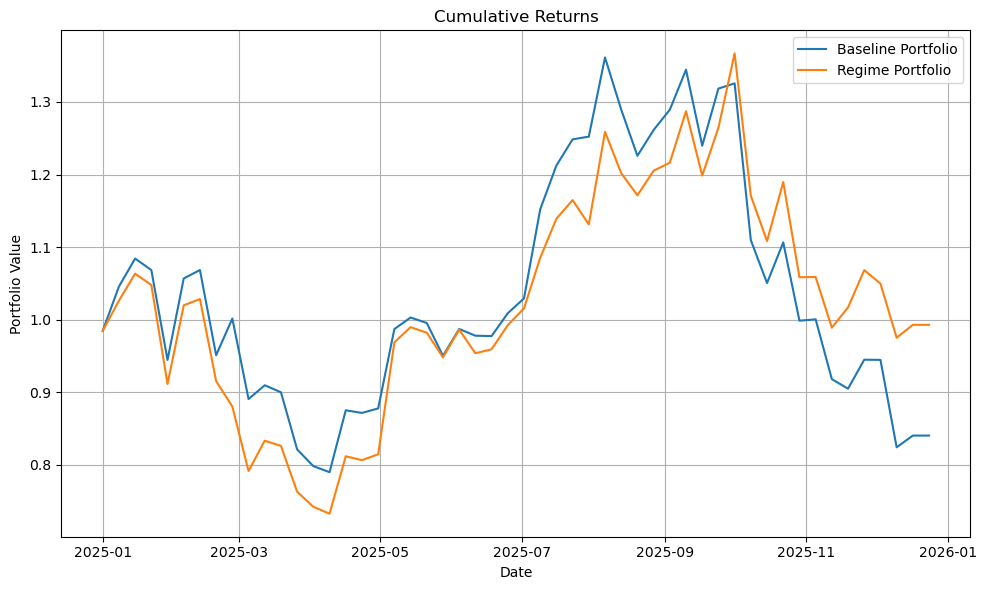

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(pd.to_datetime(cum_base.index), cum_base.values, label="Baseline Portfolio")
plt.plot(pd.to_datetime(cum_reg.index), cum_reg.values, label="Regime Portfolio")
plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()